In [2]:
!pip install polartox
!pip install ndfu


# DICES → nDFU → Polarized Trees Inference

This notebook applies Polarized Trees to DICES-350 and DICES-990.

Workflow:

1. load and preserve the existing DICES preprocessing;
2. keep only the four SCD dimensions and `Q_overall`;
3. encode `No / Unsure / Yes` as `1 / 2 / 3`;
4. perform compact validation / EDA;
5. compute nDFU per item;
6. run Polarized Trees in inference mode with the five configurations selected during synthetic model selection;
7. report F, C, P, and inference diagnostics.

There is no synthetic ground truth here, so recovery metrics are not used.



## 1. Imports and experiment configuration


In [43]:

# ============================================================
# 1. IMPORTS AND EXPERIMENT CONFIGURATION
# ============================================================

# In a fresh environment, uncomment:
# %pip install -U polartox

from pathlib import Path
from collections import Counter
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from polartox.polarized_trees import PolarizedTreesPipeline
from ndfu import dfu


SCD_DIMS = [
    "rater_gender",
    "rater_race",
    "rater_age",
    "rater_education",
]

SCALE = 3


# DICES categorical annotation -> ordered numeric signal
RATING_MAP = {
    "No": 1,
    "Unsure": 2,
    "Yes": 3,
}


# Only "Yes" is treated as the upper/toxic pole.
#
# No     = 1
# Unsure = 2
# Yes    = 3
#
# theta_pole=3 means rating >= 3 is the upper pole.
THETA_POLE = 3


# Five best configurations from synthetic model selection.
TOP5_CONFIGS = [
    {
        "rank": 1,
        "theta_filter": 0.30,
        "min_size_frac": 0.03,
        "max_depth": 8,
        "variant": "beta",
        "beta": 1.0,
        "h": 0.15,
        "relative_h": True,
        "theta_stop": 0.10,
    },
    {
        "rank": 2,
        "theta_filter": 0.20,
        "min_size_frac": 0.02,
        "max_depth": 8,
        "variant": "beta",
        "beta": 1.0,
        "h": 0.15,
        "relative_h": True,
        "theta_stop": 0.10,
    },
    {
        "rank": 3,
        "theta_filter": 0.20,
        "min_size_frac": 0.02,
        "max_depth": 4,
        "variant": "beta",
        "beta": 1.0,
        "h": 0.15,
        "relative_h": True,
        "theta_stop": 0.10,
    },
    {
        "rank": 4,
        "theta_filter": 0.40,
        "min_size_frac": 0.03,
        "max_depth": 4,
        "variant": "beta",
        "beta": 1.0,
        "h": 0.15,
        "relative_h": True,
        "theta_stop": 0.10,
    },
    {
        "rank": 5,
        "theta_filter": 0.40,
        "min_size_frac": 0.02,
        "max_depth": 8,
        "variant": "beta",
        "beta": 1.0,
        "h": 0.15,
        "relative_h": True,
        "theta_stop": 0.10,
    },
]

CONFIGS_DF = pd.DataFrame(TOP5_CONFIGS)
display(CONFIGS_DF)


,rank,theta_filter,min_size_frac,max_depth,variant,beta,h,relative_h,theta_stop
0,1,0.3,0.03,8,beta,1.0,0.15,True,0.1
1,2,0.2,0.02,8,beta,1.0,0.15,True,0.1
2,3,0.2,0.02,4,beta,1.0,0.15,True,0.1
3,4,0.4,0.03,4,beta,1.0,0.15,True,0.1
4,5,0.4,0.02,8,beta,1.0,0.15,True,0.1



## 2. Load DICES and keep the required variables

The files should be in the same annotation-level form used in the current
preprocessing: one row per annotation.

Change only the two paths below.


In [28]:
# ============================================================
# 2. LOAD DICES DATA
# ============================================================

DICES_350_PATH = Path("DICES_350.csv")
DICES_990_PATH = Path("DICES_990.csv")

df_350 = pd.read_csv(DICES_350_PATH)
df_990 = pd.read_csv(DICES_990_PATH)

print("DICES-350 shape:", df_350.shape)
print("DICES-990 shape:", df_990.shape)

DICES-350 shape: (43050, 41)
DICES-990 shape: (72103, 43)



### Filter to the variables needed by Polarized Trees

The four SCD dimensions remain categorical. We do not numerically encode
the demographic categories.


In [29]:

# ============================================================
# FILTER TO REQUIRED COLUMNS
# ============================================================

REQUIRED_COLUMNS = [
    "item_id",
    "context",
    "response",
    "rater_gender",
    "rater_race",
    "rater_age",
    "rater_education",
    "Q_overall",
    "rater_id"
]

df_350 = df_350[
    [c for c in REQUIRED_COLUMNS if c in df_350.columns]
].copy()

df_990 = df_990[
    [c for c in REQUIRED_COLUMNS if c in df_990.columns]
].copy()

missing_350 = [c for c in REQUIRED_COLUMNS if c not in df_350.columns]
missing_990 = [c for c in REQUIRED_COLUMNS if c not in df_990.columns]

assert not missing_350, f"DICES-350 missing columns: {missing_350}"
assert not missing_990, f"DICES-990 missing columns: {missing_990}"

assert df_350.columns.tolist() == REQUIRED_COLUMNS
assert df_990.columns.tolist() == REQUIRED_COLUMNS

print("DICES-350 shape:", df_350.shape)
print("DICES-990 shape:", df_990.shape)
print("Remaining columns:", df_350.columns.tolist())
print("✓ Both datasets contain exactly the required variables.")


DICES-350 shape: (43050, 9)
DICES-990 shape: (72103, 9)
Remaining columns: ['item_id', 'context', 'response', 'rater_gender', 'rater_race', 'rater_age', 'rater_education', 'Q_overall', 'rater_id']
✓ Both datasets contain exactly the required variables.



## 3. Validate the annotation-level data

We check missingness, annotation categories, number of items, and annotation
density before changing the rating representation.


In [33]:
# ============================================================
# FILTER SCD CATEGORIES FOR ANALYSIS
# ============================================================

EXCLUDED_CATEGORIES = {
    "rater_gender": [
        "Nonbinary",
        "Self-describe (below)",
    ],
    "rater_race": [
        "Other",
        "Multiracial",
    ],
    "rater_education": [
        "Other",
    ],
}

for column, categories in EXCLUDED_CATEGORIES.items():

    print(f"\n{column}")
    print("Removing:", categories)

    for category in categories:
        print(
            f"  {category}: "
            f"{(df_350[column] == category).sum()} DICES-350, "
            f"{(df_990[column] == category).sum()} DICES-990"
        )

    df_350 = df_350[
        ~df_350[column].isin(categories)
    ].copy()

    df_990 = df_990[
        ~df_990[column].isin(categories)
    ].copy()


print("\n" + "=" * 60)
print("SHAPES AFTER SCD CATEGORY FILTERING")
print("=" * 60)

print("DICES-350:", df_350.shape)
print("DICES-990:", df_990.shape)


rater_gender
Removing: ['Nonbinary', 'Self-describe (below)']
  Nonbinary: 0 DICES-350, 0 DICES-990
  Self-describe (below): 0 DICES-350, 0 DICES-990

rater_race
Removing: ['Other', 'Multiracial']
  Other: 0 DICES-350, 0 DICES-990
  Multiracial: 0 DICES-350, 0 DICES-990

rater_education
Removing: ['Other']
  Other: 0 DICES-350, 0 DICES-990

SHAPES AFTER SCD CATEGORY FILTERING
DICES-350: (35350, 9)
DICES-990: (45379, 9)


In [34]:
# ============================================================
# 3. VALIDATION AND DATASET SUMMARY
# ============================================================

ANALYSIS_COLUMNS = SCD_DIMS + ["Q_overall"]

for name, df in [("DICES-350", df_350), ("DICES-990", df_990)]:

    print("=" * 70)
    print(name)
    print("=" * 70)

    # --------------------------------------------------------
    # Basic dataset statistics
    # --------------------------------------------------------

    n_annotations = len(df)
    n_items = df["item_id"].nunique()

    print("\n[Basic statistics]")
    print("Annotations:", n_annotations)
    print("Items:", n_items)
    print("Mean annotations per item:", round(n_annotations / n_items, 2))

    # --------------------------------------------------------
    # Annotations per item
    # --------------------------------------------------------

    annotations_per_item = df.groupby("item_id").size()

    print("\n[Annotations per item]")
    print(
        annotations_per_item
        .describe()
        .loc[["min", "mean", "50%", "max"]]
    )

    # --------------------------------------------------------
    # Missing values and category distributions
    # --------------------------------------------------------

    print("\n[SCD and rating variables]")

    for col in ANALYSIS_COLUMNS:

        print(f"\n{col}")
        print("-" * 40)

        print("Missing:", df[col].isna().sum())
        print("Unique:", df[col].nunique())
        print("Counts:")
        print(df[col].value_counts().to_dict())

        # Percentage distribution
        print("Percentages:")
        print(
            (df[col].value_counts(normalize=True) * 100)
            .round(2)
            .to_dict()
        )

    # --------------------------------------------------------
    # Unique annotator profiles
    # --------------------------------------------------------

    n_profiles = df[SCD_DIMS].drop_duplicates().shape[0]

    print("\n[Annotator profiles]")
    print("Unique SCD profiles:", n_profiles)

    # --------------------------------------------------------
    # SCD intersectional profile distribution
    # --------------------------------------------------------

    profile_counts = (
        df.groupby(SCD_DIMS)
        .size()
        .sort_values(ascending=False)
    )

    print("\n[Intersectional SCD profiles]")
    print("Number of observed profiles:", len(profile_counts))
    print("Annotations per observed profile:")
    print(
        profile_counts
        .describe()
        .loc[["min", "mean", "50%", "max"]]
    )

    # --------------------------------------------------------
    # Number of unique annotator profiles per item
    # --------------------------------------------------------

    profiles_per_item = (
        df.groupby("item_id")[SCD_DIMS]
        .apply(lambda x: x.drop_duplicates().shape[0])
    )

    print("\n[Unique SCD profiles per item]")
    print(
        profiles_per_item
        .describe()
        .loc[["min", "mean", "50%", "max"]]
    )

    # --------------------------------------------------------
    # Rating distribution
    # --------------------------------------------------------

    print("\n[Overall rating distribution]")
    rating_counts = df["Q_overall"].value_counts()

    print(rating_counts.to_dict())

    print("Percentages:")
    print(
        (df["Q_overall"].value_counts(normalize=True) * 100)
        .round(2)
        .to_dict()
    )

    # --------------------------------------------------------
    # Item-level polarization opportunity
    # --------------------------------------------------------
    # Number of distinct ratings per item.
    # This is descriptive only; it is NOT the DFU measure.

    distinct_ratings_per_item = (
        df.groupby("item_id")["Q_overall"]
        .nunique()
    )

    print("\n[Rating diversity per item]")
    print(
        distinct_ratings_per_item
        .describe()
        .loc[["min", "mean", "50%", "max"]]
    )

    print(
        "Items with all three rating categories:",
        (distinct_ratings_per_item == 3).sum(),
        f"({(distinct_ratings_per_item == 3).mean() * 100:.2f}%)"
    )

    # --------------------------------------------------------
    # Validation checks
    # --------------------------------------------------------

    assert df[ANALYSIS_COLUMNS].notna().all().all()
    assert set(df["Q_overall"].unique()) == {"No", "Unsure", "Yes"}
    assert df["item_id"].nunique() > 0

    print("\n✓ Validation passed.")


# ============================================================
# 4. COMPARISON SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DATASET COMPARISON")
print("=" * 70)

summary = []

for name, df in [("DICES-350", df_350), ("DICES-990", df_990)]:

    annotations_per_item = df.groupby("item_id").size()

    summary.append({
        "Dataset": name,
        "Items": df["item_id"].nunique(),
        "Annotations": len(df),
        "Mean annotations/item": round(annotations_per_item.mean(), 2),
        "Min annotations/item": annotations_per_item.min(),
        "Max annotations/item": annotations_per_item.max(),
        "Unique SCD profiles": df[SCD_DIMS].drop_duplicates().shape[0],
        "Gender groups": df["rater_gender"].nunique(),
        "Race groups": df["rater_race"].nunique(),
        "Age groups": df["rater_age"].nunique(),
        "Education groups": df["rater_education"].nunique(),
    })

comparison = pd.DataFrame(summary)

print(comparison.to_string(index=False))

print("\n✓ All dataset checks completed.")

DICES-350

[Basic statistics]
Annotations: 35350
Items: 350
Mean annotations per item: 101.0

[Annotations per item]
min     101.0
mean    101.0
50%     101.0
max     101.0
dtype: float64

[SCD and rating variables]

rater_gender
----------------------------------------
Missing: 0
Unique: 2
Counts:
{'Woman': 19250, 'Man': 16100}
Percentages:
{'Woman': 54.46, 'Man': 45.54}

rater_race
----------------------------------------
Missing: 0
Unique: 4
Counts:
{'White': 10150, 'Black/African American': 9100, 'Asian/Asian subcontinent': 8750, 'LatinX, Latino, Hispanic or Spanish Origin': 7350}
Percentages:
{'White': 28.71, 'Black/African American': 25.74, 'Asian/Asian subcontinent': 24.75, 'LatinX, Latino, Hispanic or Spanish Origin': 20.79}

rater_age
----------------------------------------
Missing: 0
Unique: 3
Counts:
{'gen z': 16800, 'millenial': 10500, 'gen x+': 8050}
Percentages:
{'gen z': 47.52, 'millenial': 29.7, 'gen x+': 22.77}

rater_education
----------------------------------------


## 4. Convert `Q_overall` to the ordered signal

The categorical DICES annotations are represented as:

| DICES annotation | Signal |
|---|---:|
| No | 1 |
| Unsure | 2 |
| Yes | 3 |

The original categorical value is retained in `Q_overall_original`.
The mapping preserves the ordinal ordering; it does not claim that the
three levels are equal-interval measurements.


In [35]:

# ============================================================
# 4. ENCODE Q_OVERALL
# ============================================================

for df in (df_350, df_990):

    df["Q_overall_original"] = df["Q_overall"]
    df["signal"] = df["Q_overall"].map(RATING_MAP)

    assert df["signal"].notna().all()
    assert set(df["signal"].unique()) == {1, 2, 3}

print("DICES-350 signal distribution:")
print(df_350["signal"].value_counts().sort_index())

print("\nDICES-990 signal distribution:")
print(df_990["signal"].value_counts().sort_index())

display(
    pd.DataFrame({
        "annotation": ["No", "Unsure", "Yes"],
        "signal": [1, 2, 3],
    })
)

print("✓ All annotations were successfully mapped.")


DICES-350 signal distribution:
signal
1    21876
2     2104
3    11370
Name: count, dtype: int64

DICES-990 signal distribution:
signal
1    32583
2     2139
3    10657
Name: count, dtype: int64


,annotation,signal
0,No,1
1,Unsure,2
2,Yes,3


✓ All annotations were successfully mapped.


## 5. Exploratory data analysis

We examine the annotation distribution, the distributions of the four
social and demographic dimensions, and the coverage of annotator identities
across increasingly detailed SCD profiles.

For the annotations, we report the distribution of the original categorical
`Q_overall` labels.

For each SCD dimension, we report the number and proportion of annotations
belonging to each category.

We then examine annotator coverage using the unique `rater_id` identifier,
first overall and by individual SCD dimensions, followed by 2-, 3-, and
4-dimensional SCD profiles. These analyses count unique annotators rather
than annotations.

This section is descriptive only. nDFU and polarization are computed in the
following sections.

DICES-350 — Q_overall


,count,proportion
Q_overall,,
No,21876,0.618840
Unsure,2104,0.059519
Yes,11370,0.321641


DICES-990 — Q_overall


,count,proportion
Q_overall,,
No,32583,0.718019
Unsure,2139,0.047136
Yes,10657,0.234844


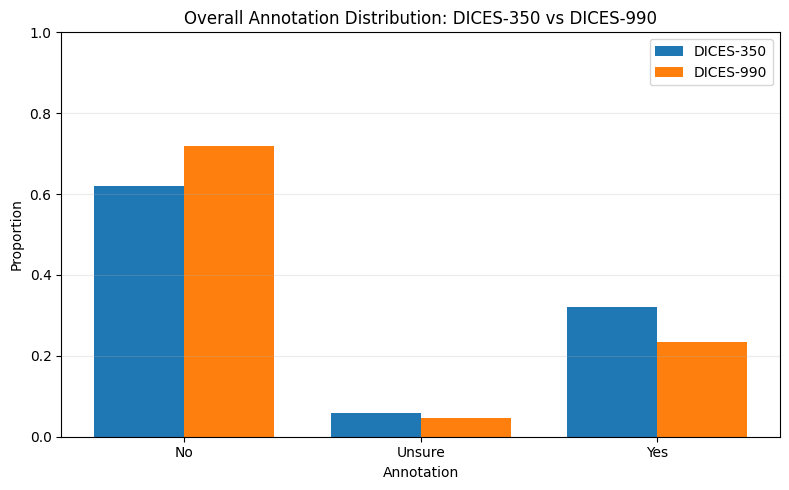

In [58]:
# ------------------------------------------------------------
# 5.1 Overall annotation distribution
#     Table + figure
# ------------------------------------------------------------

annotation_order = ["No", "Unsure", "Yes"]

# ---------- Tables ----------
for name, df in [
    ("DICES-350", df_350),
    ("DICES-990", df_990),
]:

    print("=" * 60)
    print(f"{name} — Q_overall")
    print("=" * 60)

    display(
        categorical_summary(df, "Q_overall")
        .reindex(annotation_order)
    )


# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(annotation_order))
width = 0.38

for i, (name, df) in enumerate([
    ("DICES-350", df_350),
    ("DICES-990", df_990),
]):

    proportions = (
        df["Q_overall"]
        .value_counts(normalize=True)
        .reindex(annotation_order, fill_value=0)
    )

    offset = (i - 0.5) * width

    ax.bar(
        x + offset,
        proportions.values,
        width,
        label=name
    )

ax.set_title("Overall Annotation Distribution: DICES-350 vs DICES-990")
ax.set_xlabel("Annotation")
ax.set_ylabel("Proportion")
ax.set_xticks(x)
ax.set_xticklabels(annotation_order)
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


DICES-350 — SCD dimensions

rater_gender


,count,proportion
rater_gender,,
Woman,19250,0.544554
Man,16100,0.455446



rater_race


,count,proportion
rater_race,,
White,10150,0.287129
Black/African American,9100,0.257426
Asian/Asian subcontinent,8750,0.247525
"LatinX, Latino, Hispanic or Spanish Origin",7350,0.207921



rater_age


...

,count,proportion
rater_race,,
Asian/Asian subcontinent,19885,0.438198
White,12322,0.271535
"LatinX, Latino, Hispanic or Spanish Origin",6840,0.150731
Black/African American,6332,0.139536



rater_age


,count,proportion
rater_age,,
millenial,26267,0.578836
gen x+,11666,0.257079
gen z,7446,0.164085



rater_education


,count,proportion
rater_education,,
College degree or higher,39723,0.875361
High school or below,5656,0.124639


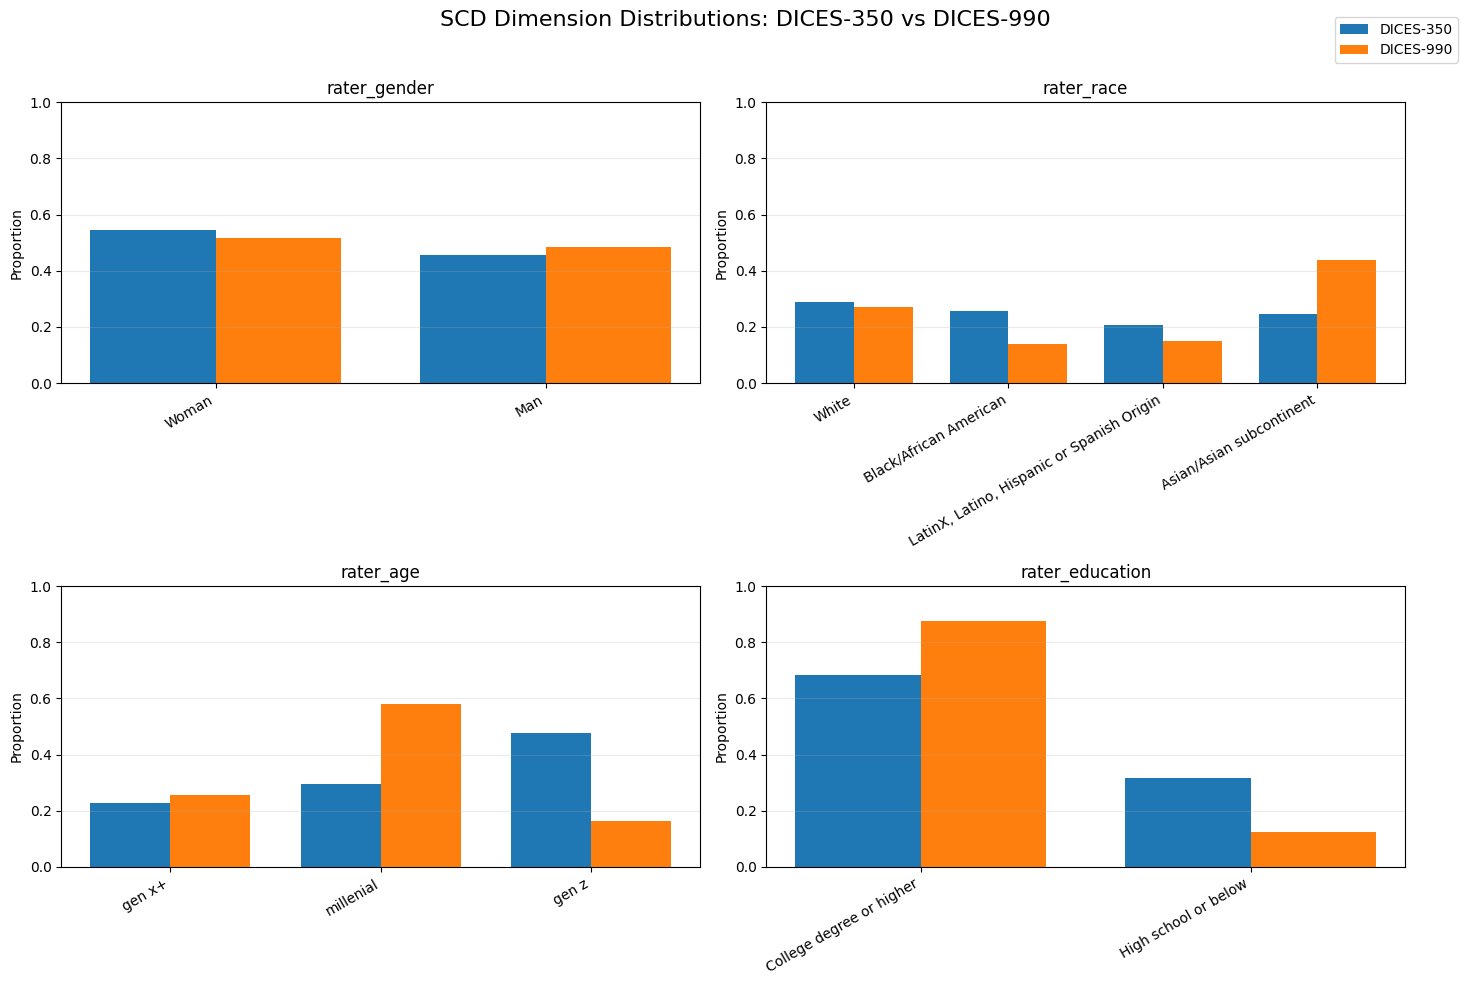

In [59]:
# ------------------------------------------------------------
# 5.2 SCD dimension distributions
#     Tables + figure
# ------------------------------------------------------------

datasets = {
    "DICES-350": df_350,
    "DICES-990": df_990,
}

# ---------- Tables ----------
for name, df in datasets.items():

    print("\n" + "=" * 60)
    print(f"{name} — SCD dimensions")
    print("=" * 60)

    for dimension in SCD_DIMS:

        print(f"\n{dimension}")

        display(
            categorical_summary(df, dimension)
        )


# ---------- Figure ----------
fig, axes = plt.subplots(
    2, 2,
    figsize=(15, 10)
)

axes = axes.flatten()

for ax, dimension in zip(axes, SCD_DIMS):

    categories = list(dict.fromkeys(
        list(df_350[dimension].dropna().unique()) +
        list(df_990[dimension].dropna().unique())
    ))

    x = np.arange(len(categories))
    width = 0.38

    for i, (name, df) in enumerate(datasets.items()):

        proportions = (
            df[dimension]
            .value_counts(normalize=True)
            .reindex(categories, fill_value=0)
        )

        offset = (i - 0.5) * width

        ax.bar(
            x + offset,
            proportions.values,
            width,
            label=name
        )

    ax.set_title(dimension)
    ax.set_ylabel("Proportion")
    ax.set_xticks(x)
    ax.set_xticklabels(
        categories,
        rotation=30,
        ha="right"
    )
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98)
)

fig.suptitle(
    "SCD Dimension Distributions: DICES-350 vs DICES-990",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()

In [65]:
# ============================================================
# 5.3 UNIQUE ANNOTATOR IDENTITY AND OVERALL COVERAGE
# ============================================================

for name, df in [
    ("DICES-350", df_350),
    ("DICES-990", df_990),
]:

    print(f"\n{'=' * 70}")
    print(f"{name} — Unique annotator coverage")
    print(f"{'=' * 70}")

    print(f"Unique annotators (rater_id): {df['rater_id'].nunique()}")
    print(f"Unique full SCD profiles: {df[SCD_DIMS].drop_duplicates().shape[0]}")

    unique_annotations_per_rater = df.groupby("rater_id").size()

    print("\nAnnotations per unique annotator:")
    display(
        unique_annotations_per_rater
        .describe()
        .loc[["min", "mean", "50%", "max"]]
        .rename("annotations")
        .to_frame()
    )


DICES-350 — Unique annotator coverage
Unique annotators (rater_id): 101
Unique full SCD profiles: 35

Annotations per unique annotator:


,annotations
min,350.0
mean,350.0
50%,350.0
max,350.0



DICES-990 — Unique annotator coverage
Unique annotators (rater_id): 106
Unique full SCD profiles: 32

Annotations per unique annotator:


,annotations
min,16.000000
mean,428.103774
50%,332.500000
max,990.000000


In [66]:
# ============================================================
# 5.4 UNIQUE ANNOTATORS BY INDIVIDUAL SCD DIMENSION
# ============================================================

for name, df in [
    ("DICES-350", df_350),
    ("DICES-990", df_990),
]:

    print(f"\n{'=' * 70}")
    print(f"{name} — Unique annotators by SCD dimension")
    print(f"{'=' * 70}")

    for dimension in SCD_DIMS:

        unique_counts = (
            df.groupby(dimension)["rater_id"]
            .nunique()
            .reset_index(name="unique_annotators")
            .sort_values("unique_annotators", ascending=False)
        )

        print(f"\n{dimension}")
        display(unique_counts)


DICES-350 — Unique annotators by SCD dimension

rater_gender


,rater_gender,unique_annotators
1,Woman,55
0,Man,46



rater_race


,rater_race,unique_annotators
3,White,29
1,Black/African American,26
0,Asian/Asian subcontinent,25
2,"LatinX, Latino, Hispanic or Spanish Origin",21



rater_age


...

,rater_race,unique_annotators
0,Asian/Asian subcontinent,53
3,White,27
2,"LatinX, Latino, Hispanic or Spanish Origin",15
1,Black/African American,11



rater_age


,rater_age,unique_annotators
2,millenial,59
0,gen x+,33
1,gen z,15



rater_education


,rater_education,unique_annotators
0,College degree or higher,90
1,High school or below,16


In [62]:
# ============================================================
# 5.5 TWO-DIMENSIONAL SCD PROFILES
# ============================================================

import itertools

all_raters = pd.concat([
    df_350[SCD_DIMS + ["rater_id"]],
    df_990[SCD_DIMS + ["rater_id"]]
]).drop_duplicates()

for dims in itertools.combinations(SCD_DIMS, 2):

    profile_counts = (
        all_raters
        .groupby(list(dims))["rater_id"]
        .nunique()
        .reset_index(name="unique_raters")
        .sort_values("unique_raters", ascending=False)
    )

    print(f"\n{' × '.join(dims)}")
    display(profile_counts)


rater_gender × rater_race


,rater_gender,rater_race,unique_raters
0,Man,Asian/Asian subcontinent,40
4,Woman,Asian/Asian subcontinent,35
7,Woman,White,30
3,Man,White,23
6,Woman,"LatinX, Latino, Hispanic or Spanish Origin",21
1,Man,Black/African American,18
5,Woman,Black/African American,17
2,Man,"LatinX, Latino, Hispanic or Spanish Origin",13



rater_gender × rater_age


,rater_gender,rater_age,unique_raters
5,Woman,millenial,44
2,Man,millenial,41
4,Woman,gen z,36
0,Man,gen x+,27
1,Man,gen z,27
3,Woman,gen x+,24



rater_gender × rater_education


...

,rater_race,rater_age,unique_raters
2,Asian/Asian subcontinent,millenial,41
0,Asian/Asian subcontinent,gen x+,22
10,White,gen z,22
11,White,millenial,18
4,Black/African American,gen z,17
8,"LatinX, Latino, Hispanic or Spanish Origin",millenial,16
9,White,gen x+,14
1,Asian/Asian subcontinent,gen z,13
7,"LatinX, Latino, Hispanic or Spanish Origin",gen z,11
5,Black/African American,millenial,10



rater_race × rater_education


,rater_race,rater_education,unique_raters
0,Asian/Asian subcontinent,College degree or higher,62
6,White,College degree or higher,39
4,"LatinX, Latino, Hispanic or Spanish Origin",College degree or higher,25
2,Black/African American,College degree or higher,24
7,White,High school or below,14
1,Asian/Asian subcontinent,High school or below,13
3,Black/African American,High school or below,11
5,"LatinX, Latino, Hispanic or Spanish Origin",High school or below,9



rater_age × rater_education


,rater_age,rater_education,unique_raters
4,millenial,College degree or higher,71
0,gen x+,College degree or higher,44
2,gen z,College degree or higher,37
3,gen z,High school or below,26
5,millenial,High school or below,14
1,gen x+,High school or below,7


In [63]:
# ============================================================
# 5.6 THREE-DIMENSIONAL SCD PROFILES
# ============================================================

for dims in itertools.combinations(SCD_DIMS, 3):

    profile_counts = (
        all_raters
        .groupby(list(dims))["rater_id"]
        .nunique()
        .reset_index(name="unique_raters")
        .sort_values("unique_raters", ascending=False)
    )

    print(f"\n{' × '.join(dims)}")
    display(profile_counts)


rater_gender × rater_race × rater_age


,rater_gender,rater_race,rater_age,unique_raters
14,Woman,Asian/Asian subcontinent,millenial,21
2,Man,Asian/Asian subcontinent,millenial,20
22,Woman,White,gen z,15
0,Man,Asian/Asian subcontinent,gen x+,12
11,Man,White,millenial,11
20,Woman,"LatinX, Latino, Hispanic or Spanish Origin",millenial,11
16,Woman,Black/African American,gen z,10
12,Woman,Asian/Asian subcontinent,gen x+,10
21,Woman,White,gen x+,8
1,Man,Asian/Asian subcontinent,gen z,8



rater_gender × rater_race × rater_education


,rater_gender,rater_race,rater_education,unique_raters
0,Man,Asian/Asian subcontinent,College degree or higher,33
8,Woman,Asian/Asian subcontinent,College degree or higher,29
14,Woman,White,College degree or higher,21
6,Man,White,College degree or higher,18
12,Woman,"LatinX, Latino, Hispanic or Spanish Origin",College degree or higher,18
2,Man,Black/African American,College degree or higher,15
10,Woman,Black/African American,College degree or higher,9
15,Woman,White,High school or below,9
11,Woman,Black/African American,High school or below,8
1,Man,Asian/Asian subcontinent,High school or below,7



rater_gender × rater_age × rater_education


,rater_gender,rater_age,rater_education,unique_raters
10,Woman,millenial,College degree or higher,39
4,Man,millenial,College degree or higher,32
0,Man,gen x+,College degree or higher,26
8,Woman,gen z,College degree or higher,21
6,Woman,gen x+,College degree or higher,18
2,Man,gen z,College degree or higher,16
9,Woman,gen z,High school or below,15
3,Man,gen z,High school or below,11
5,Man,millenial,High school or below,9
7,Woman,gen x+,High school or below,6



rater_race × rater_age × rater_education


,rater_race,rater_age,rater_education,unique_raters
4,Asian/Asian subcontinent,millenial,College degree or higher,36
0,Asian/Asian subcontinent,gen x+,College degree or higher,18
19,White,gen z,College degree or higher,14
21,White,millenial,College degree or higher,13
15,"LatinX, Latino, Hispanic or Spanish Origin",millenial,College degree or higher,13
17,White,gen x+,College degree or higher,13
2,Asian/Asian subcontinent,gen z,College degree or higher,9
8,Black/African American,gen z,College degree or higher,9
10,Black/African American,millenial,College degree or higher,9
9,Black/African American,gen z,High school or below,8


In [64]:
# ============================================================
# 5.7 FOUR-DIMENSIONAL SCD PROFILES
# ============================================================

profile_counts_4d = (
    all_raters
    .groupby(SCD_DIMS)["rater_id"]
    .nunique()
    .reset_index(name="unique_raters")
    .sort_values("unique_raters", ascending=False)
)

display(profile_counts_4d)

,rater_gender,rater_race,rater_age,rater_education,unique_raters
25,Woman,Asian/Asian subcontinent,millenial,College degree or higher,20
4,Man,Asian/Asian subcontinent,millenial,College degree or higher,16
0,Man,Asian/Asian subcontinent,gen x+,College degree or higher,11
38,Woman,White,gen z,College degree or higher,10
34,Woman,"LatinX, Latino, Hispanic or Spanish Origin",millenial,College degree or higher,10
19,Man,White,millenial,College degree or higher,9
36,Woman,White,gen x+,College degree or higher,7
21,Woman,Asian/Asian subcontinent,gen x+,College degree or higher,7
6,Man,Black/African American,gen x+,College degree or higher,6
2,Man,Asian/Asian subcontinent,gen z,College degree or higher,6



## 6. Compute nDFU per item

Polarized Trees computes nDFU from the **full annotation distribution of
each item**. It is not calculated separately for gender, race, age, or
education.

For each `item_id`, we construct the histogram over signals `1, 2, 3` and
call the installed `ndfu` implementation. The helper below follows the
project's existing nDFU notebook implementation and does not reimplement
the metric.


In [ ]:

# ============================================================
# 6. NDFU PER ITEM
# ============================================================

def ndfu_for_histogram(hist):
    hist = np.asarray(hist, dtype=float)
    total = hist.sum()

    if total == 0:
        return np.nan

    p = hist / total
    value = dfu(p)

    if np.isscalar(value):
        return float(value)

    if isinstance(value, dict):
        for key in ("ndfu", "nDFU", "dfu"):
            if key in value:
                return float(value[key])

    if isinstance(value, (tuple, list, np.ndarray)):
        arr = np.asarray(value).ravel()
        if arr.size == 1:
            return float(arr[0])

    raise TypeError(
        "Could not interpret ndFu.dfu output. "
        "Inspect dfu(...) and adapt only this helper."
    )


def compute_item_ndfu(df, scale=3):
    rows = []

    for item_id, group in df.groupby("item_id", sort=True):

        histogram = (
            group["signal"]
            .value_counts()
            .reindex(range(1, scale + 1), fill_value=0)
            .to_numpy()
        )

        rows.append({
            "item_id": item_id,
            "ndfu": ndfu_for_histogram(histogram),
            "n_annotations": len(group),
            "count_no": histogram[0],
            "count_unsure": histogram[1],
            "count_yes": histogram[2],
        })

    return pd.DataFrame(rows)


ndfu_350 = compute_item_ndfu(df_350, SCALE)
ndfu_990 = compute_item_ndfu(df_990, SCALE)

print("DICES-350 nDFU summary:")
display(ndfu_350["ndfu"].describe())

print("\nDICES-990 nDFU summary:")
display(ndfu_990["ndfu"].describe())

assert len(ndfu_350) == df_350["item_id"].nunique()
assert len(ndfu_990) == df_990["item_id"].nunique()

print("✓ One nDFU value was computed for every item.")


DICES-350 nDFU summary:


,ndfu
count,350.000000
mean,0.303220
std,0.211709
min,0.000000
25%,0.134318
50%,0.243223
75%,0.426154
max,0.830189



DICES-990 nDFU summary:


,ndfu
count,990.000000
mean,0.252339
std,0.226879
min,0.000000
25%,0.071864
50%,0.170732
75%,0.387097
max,0.913043


✓ One nDFU value was computed for every item.


DICES-350 nDFU values: 350
DICES-990 nDFU values: 990
DICES-350 range: 0.000 to 0.830
DICES-990 range: 0.000 to 0.913


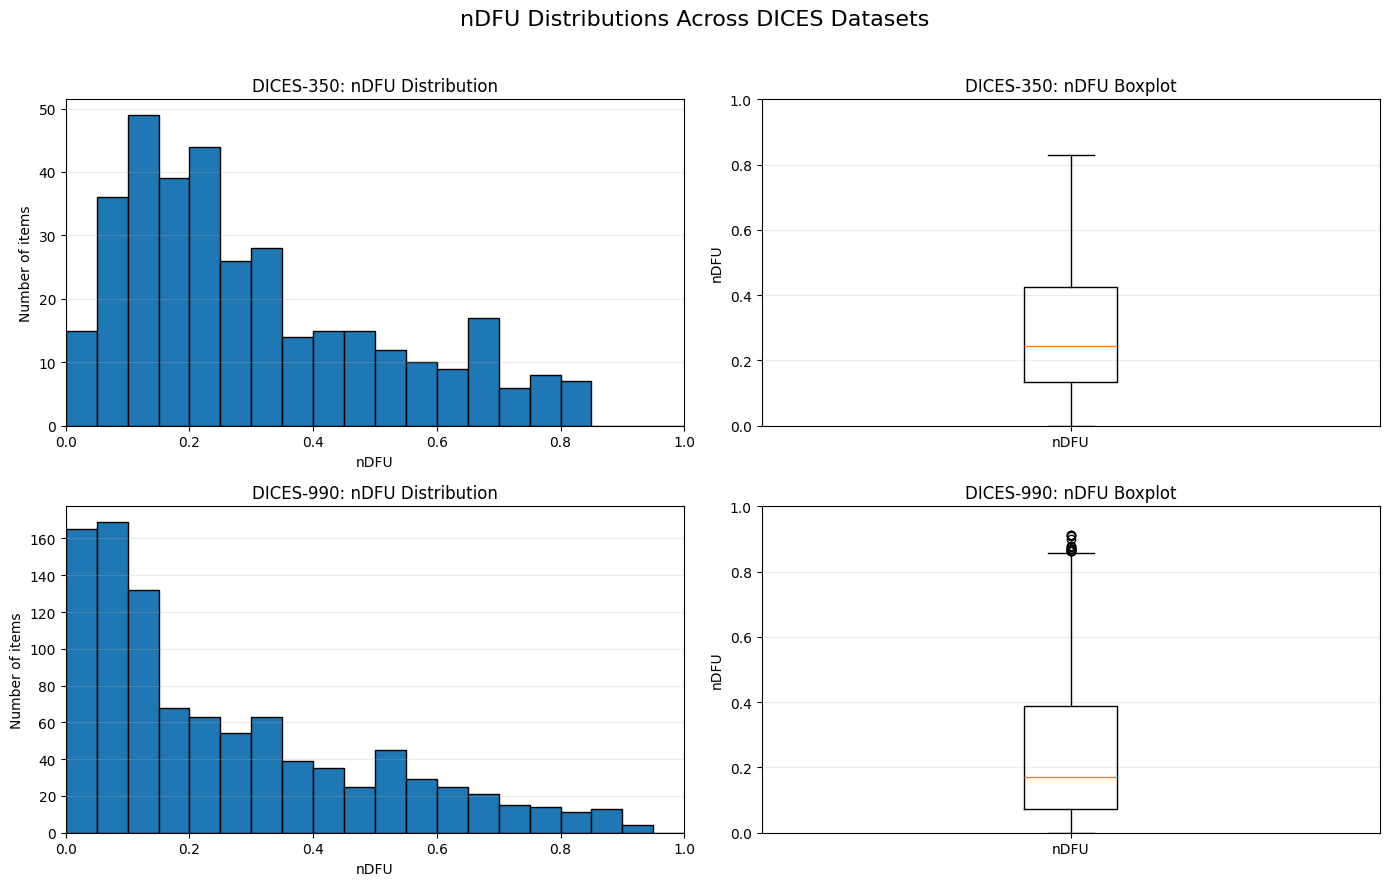

In [ ]:
# ============================================================
# nDFU DISTRIBUTION AND BOXPLOT
# ============================================================

# Extract only the nDFU values
if isinstance(ndfu_350, pd.DataFrame):
    values_350 = pd.to_numeric(
        ndfu_350["ndfu"],
        errors="coerce"
    ).dropna().to_numpy()
else:
    values_350 = pd.to_numeric(
        pd.Series(ndfu_350),
        errors="coerce"
    ).dropna().to_numpy()


if isinstance(ndfu_990, pd.DataFrame):
    values_990 = pd.to_numeric(
        ndfu_990["ndfu"],
        errors="coerce"
    ).dropna().to_numpy()
else:
    values_990 = pd.to_numeric(
        pd.Series(ndfu_990),
        errors="coerce"
    ).dropna().to_numpy()


# Sanity check
print("DICES-350 nDFU values:", len(values_350))
print("DICES-990 nDFU values:", len(values_990))

print(
    f"DICES-350 range: {values_350.min():.3f} "
    f"to {values_350.max():.3f}"
)

print(
    f"DICES-990 range: {values_990.min():.3f} "
    f"to {values_990.max():.3f}"
)


# ============================================================
# PLOTS
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 9)
)

datasets = [
    ("DICES-350", values_350),
    ("DICES-990", values_990),
]

for row, (name, values) in enumerate(datasets):

    # --------------------------------------------------------
    # Distribution
    # --------------------------------------------------------
    axes[row, 0].hist(
        values,
        bins=20,
        range=(0, 1),
        edgecolor="black"
    )

    axes[row, 0].set_title(
        f"{name}: nDFU Distribution"
    )
    axes[row, 0].set_xlabel("nDFU")
    axes[row, 0].set_ylabel("Number of items")
    axes[row, 0].set_xlim(0, 1)
    axes[row, 0].grid(
        axis="y",
        alpha=0.25
    )

    # --------------------------------------------------------
    # Boxplot
    # --------------------------------------------------------
    axes[row, 1].boxplot(
        values
    )

    axes[row, 1].set_title(
        f"{name}: nDFU Boxplot"
    )
    axes[row, 1].set_ylabel("nDFU")
    axes[row, 1].set_ylim(0, 1)
    axes[row, 1].set_xticks([1])
    axes[row, 1].set_xticklabels(["nDFU"])
    axes[row, 1].grid(
        axis="y",
        alpha=0.25
    )


fig.suptitle(
    "nDFU Distributions Across DICES Datasets",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()


## 7. Inspect nDFU and the five filtering thresholds

This is the first actual polarization analysis.

The five selected configurations use `theta_filter` values of 0.20, 0.30,
or 0.40. The table shows how many DICES items would be retained at each
threshold.

The Polarized Trees pipeline performs the actual filtering again during
inference; this section is only a diagnostic check.


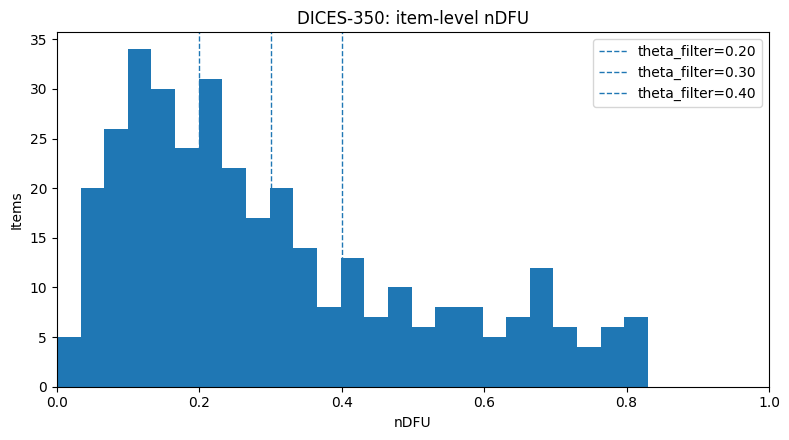

DICES-350


,rank,theta_filter,items,retained,retention_rate
0,1,0.3,350,141,0.402857
1,2,0.2,350,211,0.602857
2,3,0.2,350,211,0.602857
3,4,0.4,350,99,0.282857
4,5,0.4,350,99,0.282857


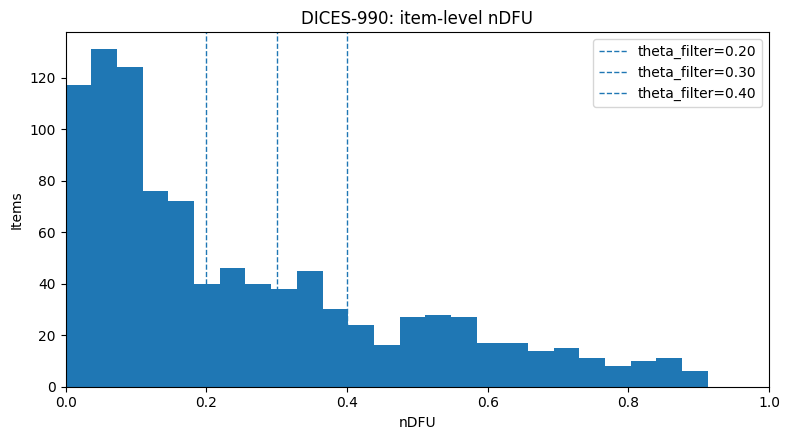

DICES-990


,rank,theta_filter,items,retained,retention_rate
0,1,0.3,990,341,0.344444
1,2,0.2,990,456,0.460606
2,3,0.2,990,456,0.460606
3,4,0.4,990,237,0.239394
4,5,0.4,990,237,0.239394


In [ ]:
# ============================================================
# 7. NDFU DISTRIBUTION + FILTERING DIAGNOSTIC
# ============================================================

def plot_ndfu_distribution(ndfu_df, dataset_name):

    plt.figure(figsize=(8, 4.5))
    plt.hist(ndfu_df["ndfu"].dropna(), bins=25)

    for theta in sorted({
        cfg["theta_filter"] for cfg in TOP5_CONFIGS
    }):
        plt.axvline(
            theta,
            linestyle="--",
            linewidth=1,
            label=f"theta_filter={theta:.2f}",
        )

    plt.xlabel("nDFU")
    plt.ylabel("Items")
    plt.title(f"{dataset_name}: item-level nDFU")
    plt.xlim(0, 1)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


def filtering_summary(ndfu_df, dataset_name):

    rows = []

    for cfg in TOP5_CONFIGS:

        theta = cfg["theta_filter"]
        retained = (ndfu_df["ndfu"] >= theta).sum()
        total = len(ndfu_df)

        rows.append({
            "rank": cfg["rank"],
            "theta_filter": theta,
            "items": total,
            "retained": retained,
            "retention_rate": retained / total,
        })

    print(dataset_name)
    display(pd.DataFrame(rows))


plot_ndfu_distribution(ndfu_350, "DICES-350")
filtering_summary(ndfu_350, "DICES-350")

plot_ndfu_distribution(ndfu_990, "DICES-990")
filtering_summary(ndfu_990, "DICES-990")



## 8. Prepare the annotation dataframe for Polarized Trees

The package expects one row per annotation with `text_id`, `rating`, and
the candidate SCD dimensions.

DICES is therefore renamed as follows:

- `item_id` → `text_id`
- `signal` → `rating`
- `rater_gender` → `gender`
- `rater_race` → `race`
- `rater_age` → `age`
- `rater_education` → `education`

`context` and `response` are not required by the algorithm and are not
passed to it.


In [ ]:
def prepare_for_polarized_trees(df):

    dataset = df[
        [
            "item_id",
            "rater_gender",
            "rater_race",
            "rater_age",
            "rater_education",
            "signal",
        ]
    ].copy()

    dataset = dataset.rename(columns={
        "item_id": "text_id",
        "rater_gender": "gender",
        "rater_race": "race",
        "rater_age": "age",
        "rater_education": "education",
        "signal": "rating",
    })

    dataset["annotator_id"] = np.arange(len(dataset))

    return dataset[
        [
            "text_id",
            "annotator_id",
            "gender",
            "race",
            "age",
            "education",
            "rating",
        ]
    ]


pt_350 = prepare_for_polarized_trees(df_350)
pt_990 = prepare_for_polarized_trees(df_990)

EXPECTED_COLUMNS = [
    "text_id",
    "annotator_id",
    "gender",
    "race",
    "age",
    "education",
    "rating",
]

assert pt_350.columns.tolist() == EXPECTED_COLUMNS
assert pt_990.columns.tolist() == EXPECTED_COLUMNS

assert pt_350["rating"].isin([1, 2, 3]).all()
assert pt_990["rating"].isin([1, 2, 3]).all()

PT_SCD_DIMS = ["gender", "race", "age", "education"]

assert pt_350[PT_SCD_DIMS].notna().all().all()
assert pt_990[PT_SCD_DIMS].notna().all().all()

print("DICES-350 Polarized Trees input:", pt_350.shape)
print("DICES-990 Polarized Trees input:", pt_990.shape)

display(pt_350.head())

DICES-350 Polarized Trees input: (35350, 7)
DICES-990 Polarized Trees input: (45379, 7)


,text_id,annotator_id,gender,race,age,education,rating
1,173,0,Woman,White,gen x+,College degree or higher,1
2,173,1,Woman,White,gen x+,College degree or higher,3
3,173,2,Woman,Black/African American,millenial,College degree or higher,1
4,173,3,Woman,"LatinX, Latino, Hispanic or Spanish Origin",millenial,College degree or higher,1
5,173,4,Man,Black/African American,millenial,College degree or higher,1


## 9. Run Polarized Trees in inference mode

The five highest-performing configurations identified on the synthetic
benchmark are applied unchanged to DICES-350 and DICES-990.

No DICES ground truth is supplied. The evaluation therefore operates in
inference mode and reports the resulting dimension frequency (F),
subgroup pole consistency (C), subgroup polarization reduction (P),
and inference diagnostics rather than recovery metrics.

In [ ]:
PT_DIMS = [
    "gender",
    "race",
    "age",
    "education",
]

In [ ]:

# ============================================================
# 9. RUN ALL FIVE CONFIGURATIONS
# ============================================================

def make_pipeline(config):

    return PolarizedTreesPipeline(
        dims=PT_DIMS,
        scale=SCALE,
        theta_filter=config["theta_filter"],
        min_size_frac=config["min_size_frac"],
        max_depth=config["max_depth"],
        variant=config["variant"],
        beta=config["beta"],
        h=config["h"],
        relative_h=config["relative_h"],
        theta_stop=config["theta_stop"],
        theta_pole=THETA_POLE,
    )


inference_results = {
    "DICES-350": {},
    "DICES-990": {},
}


for config in TOP5_CONFIGS:

    rank = config["rank"]

    print("=" * 70)
    print(f"Configuration {rank}")
    print(config)
    print("=" * 70)

    pipe_350 = make_pipeline(config)
    result_350 = pipe_350.run_full_evaluation(
        pt_350,
        ground_truth=None,
    )

    inference_results["DICES-350"][rank] = {
        "config": config,
        "pipeline": pipe_350,
        "results": result_350,
    }

    print("DICES-350 complete.")

    pipe_990 = make_pipeline(config)
    result_990 = pipe_990.run_full_evaluation(
        pt_990,
        ground_truth=None,
    )

    inference_results["DICES-990"][rank] = {
        "config": config,
        "pipeline": pipe_990,
        "results": result_990,
    }

    print("DICES-990 complete.")


Configuration 1
{'rank': 1, 'theta_filter': 0.3, 'min_size_frac': 0.03, 'max_depth': 8, 'variant': 'beta', 'beta': 1.0, 'h': 0.15, 'relative_h': True, 'theta_stop': 0.1}
=== diagnostics ===
  retention_rate: 0.40285714285714286
  mean_leaves: 4.73758865248227
  mean_depth: 2.155688622754491
  mean_residual_ndfu: 0.3450740252092363
  mean_top_split_prg: 0.13799568403538778
  indeterminate_rate: 0.0718562874251497
  dims_never_used: []
DICES-350 complete.
=== diagnostics ===
  retention_rate: 0.34444444444444444
  mean_leaves: 5.976539589442815
  mean_depth: 2.10549558390579
  mean_residual_ndfu: 0.34840094054171183
  mean_top_split_prg: 0.14175121788414566
  indeterminate_rate: 0.14965652600588814
  dims_never_used: []
DICES-990 complete.
Configuration 2
{'rank': 2, 'theta_filter': 0.2, 'min_size_frac': 0.02, 'max_depth': 8, 'variant': 'beta', 'beta': 1.0, 'h': 0.15, 'relative_h': True, 'theta_stop': 0.1}
=== diagnostics ===
  retention_rate: 0.6028571428571429
  mean_leaves: 5.31279620

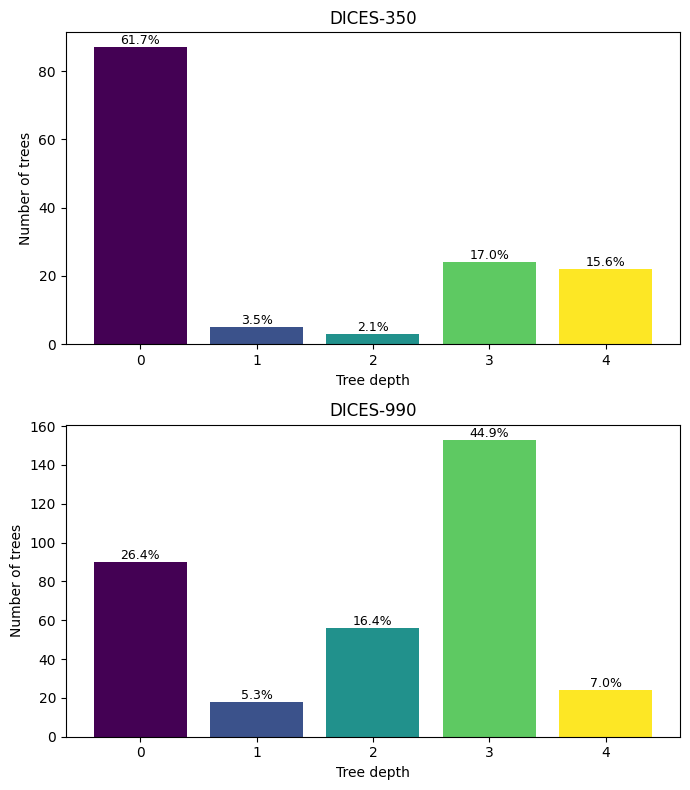

In [ ]:
# Run the five benchmark-selected configurations on DICES-350 and DICES-990.
# No DICES ground truth is provided, so this evaluates Polarized Trees in
# inference mode and stores F, C, P, and diagnostic outputs for analysis.

fig, axes = plt.subplots(2, 1, figsize=(7, 8))

for ax, dataset in zip(axes, ["DICES-350", "DICES-990"]):

    pipe = inference_results[dataset][1]["pipeline"]
    trees = pipe.trees_

    depth_counts = Counter()

    for text_id, tree_data in trees.items():
        leaves, root = tree_data

        if leaves:
            depth = max(len(leaf["path"]) for leaf in leaves)
        else:
            depth = 0

        depth_counts[depth] += 1

    depths = sorted(depth_counts)
    counts = [depth_counts[d] for d in depths]
    total = sum(counts)
    percentages = [100 * c / total for c in counts]

    colors = plt.cm.viridis(
        [i / max(len(depths) - 1, 1) for i in range(len(depths))]
    )

    bars = ax.bar(depths, counts, color=colors)

    for bar, percentage in zip(bars, percentages):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{percentage:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(dataset)
    ax.set_xlabel("Tree depth")
    ax.set_ylabel("Number of trees")
    ax.set_xticks(depths)

fig.tight_layout()
plt.show()


## 10. Compare inference diagnostics

These diagnostics are the first corpus-level results to inspect across
the five configurations.

No Jaccard, precision, recall, or exact-match score is computed because
the real DICES data do not contain ground truth for the SCD sources of
polarization.


In [ ]:

# ============================================================
# 10. DIAGNOSTICS
# ============================================================

def diagnostics_table(dataset_name):

    rows = []

    for rank in sorted(inference_results[dataset_name]):

        entry = inference_results[dataset_name][rank]
        diagnostics = entry["results"]["diagnostics"]

        rows.append({
            "rank": rank,
            "theta_filter": entry["config"]["theta_filter"],
            "min_size_frac": entry["config"]["min_size_frac"],
            "max_depth": entry["config"]["max_depth"],
            **diagnostics,
        })

    return pd.DataFrame(rows)


diagnostics_350 = diagnostics_table("DICES-350")
diagnostics_990 = diagnostics_table("DICES-990")

print("DICES-350")
display(diagnostics_350)

print("\nDICES-990")
display(diagnostics_990)


DICES-350


,rank,theta_filter,min_size_frac,max_depth,retention_rate,mean_leaves,mean_depth,mean_residual_ndfu,mean_top_split_prg,indeterminate_rate,dims_never_used
0,1,0.3,0.03,8,0.402857,4.737589,2.155689,0.345074,0.137996,0.071856,[]
1,2,0.2,0.02,8,0.602857,5.312796,2.355040,0.312197,0.113380,0.106155,[]
2,3,0.2,0.02,4,0.602857,5.312796,2.355040,0.312197,0.113380,0.106155,[]
3,4,0.4,0.03,4,0.282857,4.555556,2.133038,0.367131,0.166994,0.086475,[]
4,5,0.4,0.02,8,0.282857,5.303030,2.375238,0.352208,0.166994,0.123810,[]



DICES-990


,rank,theta_filter,min_size_frac,max_depth,retention_rate,mean_leaves,mean_depth,mean_residual_ndfu,mean_top_split_prg,indeterminate_rate,dims_never_used
0,1,0.3,0.03,8,0.344444,5.976540,2.105496,0.348401,0.141751,0.149657,[]
1,2,0.2,0.02,8,0.460606,6.052632,2.083696,0.327306,0.128647,0.136594,[]
2,3,0.2,0.02,4,0.460606,6.052632,2.083696,0.327306,0.128647,0.136594,[]
3,4,0.4,0.03,4,0.239394,5.763713,2.084919,0.368112,0.161413,0.152269,[]
4,5,0.4,0.02,8,0.239394,5.763713,2.084919,0.368112,0.161413,0.152269,[]



## 11. F, C, and P results

For real-data inference:

- **F** = Dimension Frequency;
- **C** = Subgroup Pole Consistency;
- **P** = Subgroup PRG.

These are the main dataset-level Polarized Trees outputs.


In [ ]:
def show_F(dataset_name, rank):
    results = inference_results[dataset_name][rank]["results"]

    print("=" * 70)
    print(f"{dataset_name} — Configuration {rank}")
    print("=" * 70)
    print("\nF — Dimension Frequency")
    display(results["F"])


def show_C(dataset_name, rank, top_n=20):
    results = inference_results[dataset_name][rank]["results"]

    print("=" * 70)
    print(f"{dataset_name} — Configuration {rank}")
    print("=" * 70)
    print(f"\nC — Subgroup Pole Consistency (top {top_n})")
    display(results["C"].head(top_n))


def show_P(dataset_name, rank, top_n=20):
    results = inference_results[dataset_name][rank]["results"]

    print("=" * 70)
    print(f"{dataset_name} — Configuration {rank}")
    print("=" * 70)
    print(f"\nP — Subgroup PRG (top {top_n})")
    display(results["P"].head(top_n))

In [ ]:
show_F("DICES-350", rank=1)
show_C("DICES-350", rank=1)
show_P("DICES-350", rank=1)

show_F("DICES-990", rank=1)
show_C("DICES-990", rank=1)
show_P("DICES-990", rank=1)

DICES-350 — Configuration 1

F — Dimension Frequency


depth,1,2,3,4
dim,,,,
age,9,52,20,6
education,5,28,44,5
gender,5,40,46,11
race,35,20,3,1


DICES-350 — Configuration 1

C — Subgroup Pole Consistency (top 20)


,n_s,frac_toxic,frac_civil
subgroup,,,
(),87,0.298851,0.701149
"((age, gen x+), (race, LatinX, Latino, Hispanic or Spanish Origin))",22,0.727273,0.272727
"((gender, Woman), (race, Asian/Asian subcontinent))",18,0.777778,0.222222
"((age, millenial), (race, Black/African American))",15,0.466667,0.533333
"((gender, Man), (race, Asian/Asian subcontinent))",14,0.000000,1.000000
"((age, gen x+), (race, Black/African American))",13,0.307692,0.692308
"((age, millenial), (gender, Man), (race, LatinX, Latino, Hispanic or Spanish Origin))",13,0.461538,0.538462
"((age, gen z), (education, High school or below), (race, LatinX, Latino, Hispanic or Spanish Origin))",13,0.846154,0.153846
"((age, gen z), (education, College degree or higher), (race, LatinX, Latino, Hispanic or Spanish Origin))",11,0.363636,0.636364


DICES-350 — Configuration 1

P — Subgroup PRG (top 20)


...

depth,1,2,3,4
dim,,,,
age,56,124,81,10
education,18,64,53,0
gender,41,203,123,13
race,136,77,22,3


DICES-990 — Configuration 1

C — Subgroup Pole Consistency (top 20)


,n_s,frac_toxic,frac_civil
subgroup,,,
"((race, LatinX, Latino, Hispanic or Spanish Origin),)",92,0.119565,0.880435
(),89,0.202247,0.797753
"((gender, Man), (race, Black/African American))",74,0.189189,0.810811
"((gender, Woman), (race, Black/African American))",69,0.405797,0.594203
"((age, millenial), (gender, Woman), (race, Asian/Asian subcontinent))",57,0.368421,0.631579
"((race, Black/African American),)",56,0.232143,0.767857
"((race, Asian/Asian subcontinent),)",53,0.358491,0.641509
"((age, millenial), (gender, Man), (race, Asian/Asian subcontinent))",49,0.428571,0.571429
"((race, White),)",41,0.121951,0.878049


DICES-990 — Configuration 1

P — Subgroup PRG (top 20)


,n_s,mean_prg
subgroup,,
"((age, gen x+), (education, High school or below), (race, Asian/Asian subcontinent))",2,0.391667
"((age, millenial), (education, High school or below), (gender, Woman))",1,0.380952
"((age, millenial), (education, College degree or higher), (gender, Woman), (race, White))",3,0.361538
"((age, gen x+), (education, College degree or higher), (gender, Woman), (race, Asian/Asian subcontinent))",4,0.341071
"((age, millenial), (education, College degree or higher), (gender, Man), (race, White))",5,0.277926
"((age, gen x+), (education, College degree or higher), (gender, Man), (race, White))",2,0.271605
"((age, gen z), (gender, Man))",34,0.269300
"((age, gen z), (gender, Woman))",39,0.258720
"((age, gen x+), (gender, Woman), (race, White))",27,0.256444


### Configuration 1 — Dataset-Level Results

#### DICES-350

- **F — Dimension Frequency:** `gender` and `age` are the most frequently used dimensions at intermediate depths, while `race` is used predominantly at the root (depth 1) and becomes much less frequent at deeper levels. `education` is used mainly at depths 2–3.
- **C — Subgroup Pole Consistency:** The discovered subgroups show substantial variation in pole alignment. Several subgroups are strongly associated with the toxic pole, while others are strongly civil-oriented. For example, the `Woman × Asian` subgroup is predominantly toxic (0.78), whereas `Man × Asian` is entirely civil in this sample (1.00). The results therefore reveal heterogeneous polarization patterns across annotator subgroups rather than a single dominant direction.
- **P — Subgroup PRG:** The strongest PRG values are concentrated in multi-dimensional subgroups, with the highest reaching approximately **0.42**. The strongest contributors involve combinations of `age`, `education`, `gender`, and `race`, indicating that polarization can be associated with interactions between annotator characteristics rather than individual dimensions alone.

#### DICES-990

- **F — Dimension Frequency:** `gender` is the most frequently selected dimension, particularly at depths 2–3, while `race` dominates the root-level splits. `age` is also frequently used at intermediate depths, whereas `education` is used less often and does not appear at depth 4.
- **C — Subgroup Pole Consistency:** The larger dataset reveals clearer and more stable subgroup patterns. Several subgroups are strongly civil-oriented, such as `race = LatinX` (0.88 civil) and `race = White` (0.88 civil), while others show strong toxic alignment, such as `age = gen z × gender = Man` (0.81 toxic). This again indicates substantial heterogeneity across annotator subgroups.
- **P — Subgroup PRG:** The highest PRG is approximately **0.39**, with the strongest contributors again being multi-dimensional subgroups. At the same time, several relatively large subgroups (e.g., `gen z × gender`) show moderate PRG, suggesting that both subgroup size and interaction structure contribute to the detected polarization.

### Overall observation

Across both datasets, Polarized Trees identifies **non-uniform polarization associated with annotator characteristics**. `race`, `gender`, and `age` are repeatedly selected by the trees, while the strongest subgroup-level PRG values frequently arise from **combinations of multiple SCD dimensions**. The C and P analyses also show that different subgroups can align with opposite polarization poles, supporting the use of subgroup-level analysis rather than relying only on aggregate annotator effects.


## 12. Inspect configurations 2–5

The analyses have already been run, so inspecting the remaining
configurations does not rerun the trees.


In [ ]:

# ============================================================
# 12. INSPECT CONFIGURATIONS 2–5
# ============================================================

for dataset_name in ["DICES-350", "DICES-990"]:

    print("\n" + "#" * 80)
    print(dataset_name)
    print("#" * 80)

    for rank in [2, 3, 4, 5]:

        results = inference_results[dataset_name][rank]["results"]

        print(f"\n--- Configuration {rank} ---")

        print("F:")
        display(results["F"])

        print("C:")
        display(results["C"].head(10))

        print("P:")
        display(results["P"].head(10))



################################################################################
DICES-350
################################################################################

--- Configuration 2 ---
F:


depth,1,2,3,4
dim,,,,
age,16,72,67,11
education,5,44,54,24
gender,8,53,105,29
race,52,31,7,0


C:


,n_s,frac_toxic,frac_civil
subgroup,,,
(),130,0.269231,0.730769
"((age, gen x+), (gender, Woman), (race, Asian/Asian subcontinent))",27,1.000000,0.000000
"((age, gen x+), (gender, Man), (race, Asian/Asian subcontinent))",22,0.090909,0.909091
"((age, millenial), (gender, Woman), (race, Asian/Asian subcontinent))",22,0.363636,0.636364
"((age, millenial), (race, Black/African American))",21,0.428571,0.571429
"((age, gen x+), (gender, Woman), (race, LatinX, Latino, Hispanic or Spanish Origin))",20,0.800000,0.200000
"((age, gen x+), (race, Black/African American))",20,0.300000,0.700000
"((age, millenial), (gender, Man), (race, LatinX, Latino, Hispanic or Spanish Origin))",20,0.550000,0.450000
"((age, gen z), (gender, Man), (race, Asian/Asian subcontinent))",19,0.052632,0.947368


P:


...

depth,1,2,3,4
dim,,,,
age,42,79,63,5
education,10,43,34,0
gender,30,134,72,7
race,85,59,14,2


C:


,n_s,frac_toxic,frac_civil
subgroup,,,
(),69,0.159420,0.840580
"((race, LatinX, Latino, Hispanic or Spanish Origin),)",56,0.142857,0.857143
"((gender, Man), (race, Black/African American))",47,0.148936,0.851064
"((gender, Woman), (race, Black/African American))",44,0.477273,0.522727
"((age, millenial), (gender, Woman), (race, Asian/Asian subcontinent))",44,0.318182,0.681818
"((age, millenial), (gender, Man), (race, Asian/Asian subcontinent))",35,0.514286,0.485714
"((race, Asian/Asian subcontinent),)",34,0.470588,0.529412
"((race, Black/African American),)",33,0.303030,0.696970
"((age, gen x+), (race, White))",29,0.655172,0.344828


P:


,n_s,mean_prg
subgroup,,
"((age, gen x+), (education, High school or below), (race, Asian/Asian subcontinent))",1,0.533333
"((age, millenial), (education, College degree or higher), (gender, Woman), (race, White))",2,0.492308
"((age, millenial), (education, College degree or higher), (gender, Woman))",1,0.380952
"((age, millenial), (education, High school or below), (gender, Woman))",1,0.380952
"((age, gen z), (education, College degree or higher), (gender, Woman))",2,0.375000
"((age, millenial), (education, College degree or higher), (gender, Man), (race, White))",3,0.344406
"((education, High school or below), (gender, Man), (race, Asian/Asian subcontinent))",2,0.324675
"((age, gen x+), (education, College degree or higher), (gender, Man), (race, White))",1,0.293210
"((age, gen x+), (education, College degree or higher), (gender, Woman), (race, White))",1,0.266667



## 13. Optional individual-tree inspection

This is only for debugging/qualitative inspection. It does not change
the corpus-level results.

We inspect the first retained item under configuration 1.


In [ ]:

# ============================================================
# 13. OPTIONAL INDIVIDUAL TREE INSPECTION
# ============================================================

def first_retained_item(dataset_name, rank=1):

    pipe = inference_results[dataset_name][rank]["pipeline"]

    if not pipe.trees_:
        return None

    return next(iter(pipe.trees_))


for dataset_name, dataset in [
    ("DICES-350", pt_350),
    ("DICES-990", pt_990),
]:

    item_id = first_retained_item(dataset_name, rank=1)

    print("=" * 70)
    print(dataset_name)
    print("First retained item:", item_id)

    if item_id is not None:

        inference_results[dataset_name][1]["pipeline"].inspect_tree(
            item_id,
            dataset,
            show_distributions=True,
        )

    else:
        print("No item passed the polarization filter.")


DICES-350
First retained item: 3

[root] nDFU=0.317
ratings (n=101):
  1: ############################## (60)
  2: ###### (11)
  3: ############### (30)
  -> LEAF [civil] p_tox=0.297 (best PRG 0.037 (relative=0.118) <= h)
DICES-990
First retained item: 0

[root] nDFU=0.857
ratings (n=45):
  1: ############################## (21)
  2: #### (3)
  3: ############################## (21)
  split on 'education' (PRG=0.179)

  [education=College degree or higher] nDFU=0.700
  ratings (n=40):
    1: ########################## (17)
    2: #### (3)
    3: ############################## (20)
    split on 'race' (PRG=0.137)

    [education=College degree or higher -> race=Asian/Asian subcontinent] nDFU=0.889
    ratings (n=17):
      1: ########################### (8)
      2:  (0)
      3: ############################## (9)
      split on 'gender' (PRG=0.224)

      [education=College degree or higher -> race=Asian/Asian subcontinent -> gender=Man] nDFU=0.250
      ratings (n=5):
        1: #####


## 14. Save F, C, P, and diagnostics

The pipeline objects are not serialized. The reproducible corpus-level
tables are saved for later analysis.


In [ ]:

# ============================================================
# 14. SAVE RESULTS
# ============================================================

RESULTS_DIR = Path("dices_polarized_trees_results")
RESULTS_DIR.mkdir(exist_ok=True)

for dataset_name in ["DICES-350", "DICES-990"]:

    dataset_dir = RESULTS_DIR / dataset_name
    dataset_dir.mkdir(exist_ok=True)

    for rank in sorted(inference_results[dataset_name]):

        result = inference_results[dataset_name][rank]["results"]

        result["F"].to_csv(
            dataset_dir / f"config_{rank}_F.csv",
            index=False,
        )

        result["C"].to_csv(
            dataset_dir / f"config_{rank}_C.csv",
            index=False,
        )

        result["P"].to_csv(
            dataset_dir / f"config_{rank}_P.csv",
            index=False,
        )


diagnostics_350.to_csv(
    RESULTS_DIR / "DICES-350_diagnostics_all_configs.csv",
    index=False,
)

diagnostics_990.to_csv(
    RESULTS_DIR / "DICES-990_diagnostics_all_configs.csv",
    index=False,
)

print("Saved results to:", RESULTS_DIR.resolve())


Saved results to: /content/dices_polarized_trees_results
